In [2]:
# End-to-End Machine Learning Pipeline: Survival Prediction (Titanic Dataset)

In [4]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("train.csv")

# First 20 rows
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# Initial data inspection

print("Shape:", df.shape)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


Shape: (891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.5230

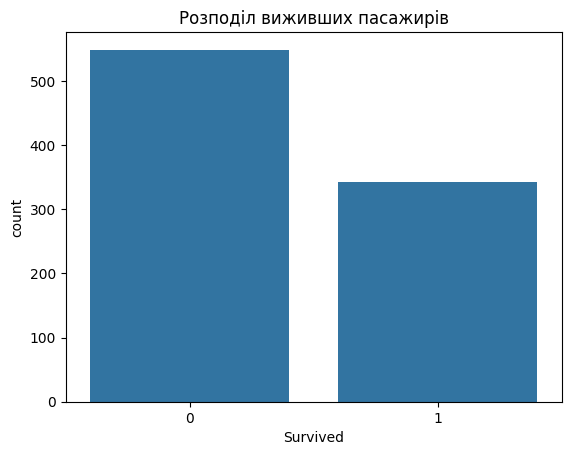

In [6]:
# --- Target Variable Distribution ---
sns.countplot(data=df, x="Survived")
plt.title("Розподіл виживших пасажирів")
plt.show()

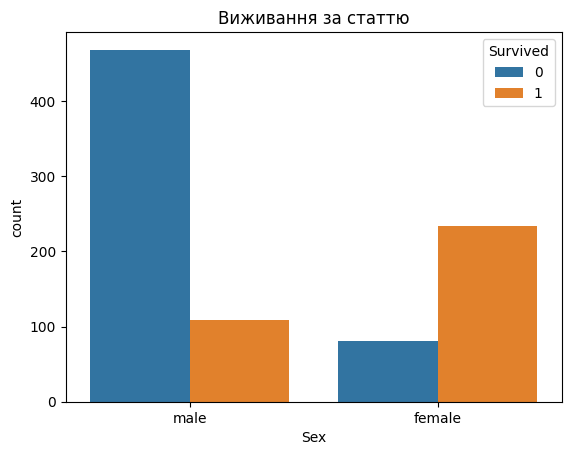

In [7]:
# --- Survival Distribution by Gender ---
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Виживання за статтю")
plt.show()

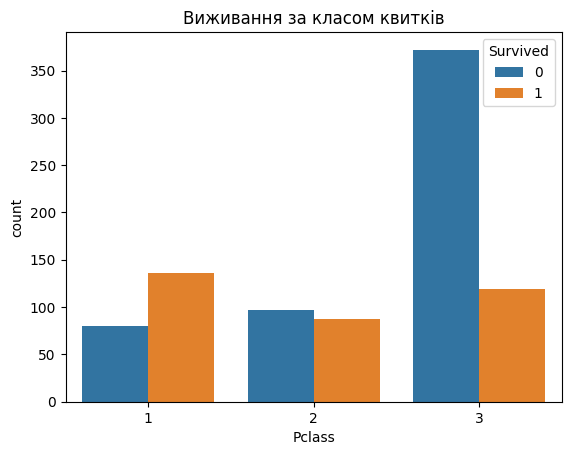

In [8]:
# --- Survival Distribution by Ticket Class ---
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Виживання за класом квитків")
plt.show()

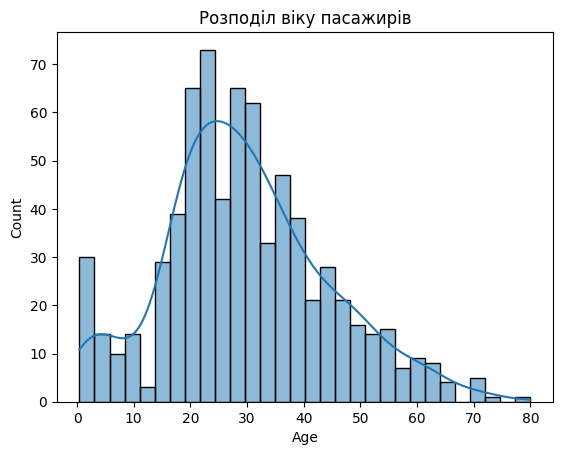

In [9]:
# --- Age Distribution ---
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Розподіл віку пасажирів")
plt.show()

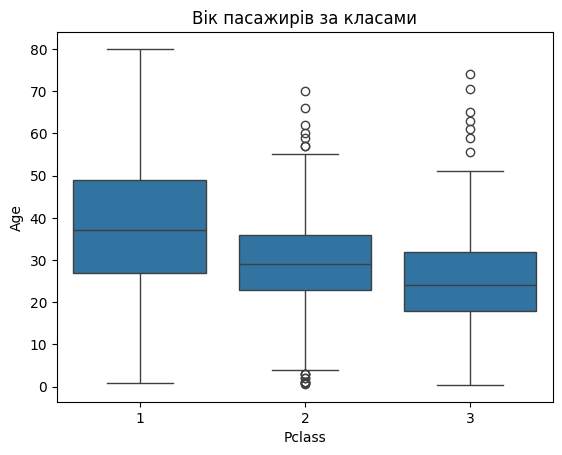

In [10]:
# --- Age by Ticket Class ---
sns.boxplot(data=df, x="Pclass", y="Age")
plt.title("Вік пасажирів за класами")
plt.show()

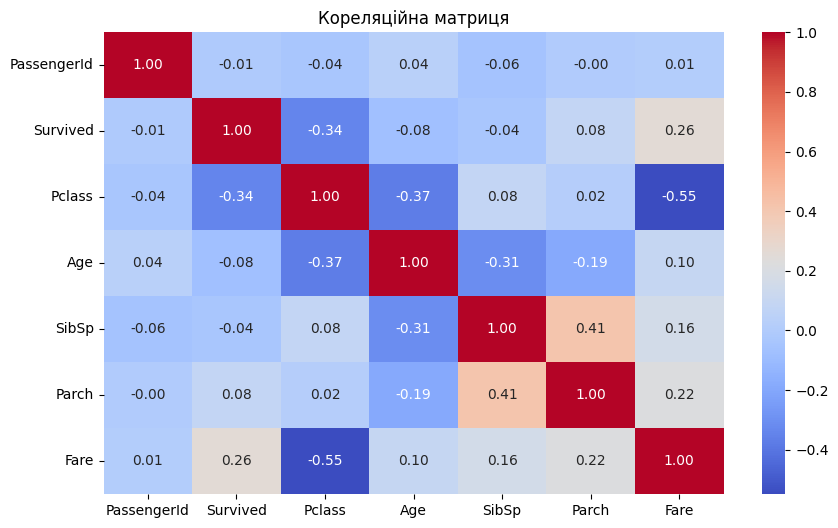

In [11]:
# --- Correlation Matrix ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляційна матриця")
plt.show()

In [ ]:
# Phase 2: Data Preprocessing & Feature Engineering
# Based on the EDA, we will handle missing values (imputation), encode categorical variables, drop irrelevant features, 
# and scale numerical data to prepare it for machine learning algorithms.

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df['Age'].describe()
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [14]:
# --- Handling Missing Values ---
# Impute 'Age' with median and 'Embarked' with the most frequent value (mode)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [15]:
# Drop 'Cabin' due to a high percentage of missing values
df = df.drop(columns=["Cabin"])

In [16]:
# --- Feature Encoding ---
# Label Encoding for binary categorical variable 'Sex'
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [17]:
# One-Hot Encoding for multi-class categorical variable 'Embarked'
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [18]:
# --- Feature Scaling ---
# Standardize numerical features to have mean=0 and variance=1
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

In [19]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.663861,1,0,PC 17599,0.786845,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,False,True
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,False,True
5,6,0,3,"Moran, Mr. James",1,-0.104637,0,0,330877,-0.478116,True,False
6,7,0,1,"McCarthy, Mr. Timothy J",1,1.893459,0,0,17463,0.395814,False,True
7,8,0,3,"Palsson, Master. Gosta Leonard",1,-2.102733,3,1,349909,-0.224083,False,True
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,-0.181487,0,2,347742,-0.424256,False,True
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,-1.180535,1,0,237736,-0.042956,False,False


In [20]:
# Phase 3: Data Splitting & Baseline Modeling
# We split the data into Training (70%), Validation (15%), and Test (15%) sets using stratified sampling to maintain class balance. 
# Then, we train three baseline classification models.

In [21]:
# --- Етап 1. Формування вибірки (train / validation / test) ---

from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
y = df["Survived"]
X = df.drop(columns=["Survived", "Name", "Ticket", "PassengerId"])

# Step 1: Extract Test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step 2: Split remaining data into Train (70%) and Validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # 0.1765 ≈ 15/85

# Result
print("Розмір тренувальної вибірки:", X_train.shape)
print("Розмір валідаційної вибірки:", X_val.shape)
print("Розмір тестової вибірки:", X_test.shape)

# Let's check the class balance
print("\nРозподіл цільової змінної:")
print("Train:\n", y_train.value_counts(normalize=True))
print("Validation:\n", y_val.value_counts(normalize=True))
print("Test:\n", y_test.value_counts(normalize=True))


Розмір тренувальної вибірки: (623, 8)
Розмір валідаційної вибірки: (134, 8)
Розмір тестової вибірки: (134, 8)

Розподіл цільової змінної:
Train:
 Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64
Validation:
 Survived
0    0.61194
1    0.38806
Name: proportion, dtype: float64
Test:
 Survived
0    0.619403
1    0.380597
Name: proportion, dtype: float64


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Initialize Models ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
tree_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# --- Train Models ---
log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# --- Generate Validation Predictions ---
val_preds_log = log_reg.predict(X_val)
val_preds_tree = tree_clf.predict(X_val)
val_preds_rf = rf_clf.predict(X_val)

# Extract probabilities for ROC-AUC
val_proba_log = log_reg.predict_proba(X_val)[:, 1]
val_proba_tree = tree_clf.predict_proba(X_val)[:, 1]
val_proba_rf = rf_clf.predict_proba(X_val)[:, 1]

print("✅ Моделі успішно навчені та готові до оцінювання.")


✅ Моделі успішно навчені та готові до оцінювання.


In [ ]:
# Phase 4: Model Interpretability & Evaluation
# Before optimizing, we analyze how models make decisions (feature importance, coefficients) and 
# evaluate their baseline performance using standard classification metrics.

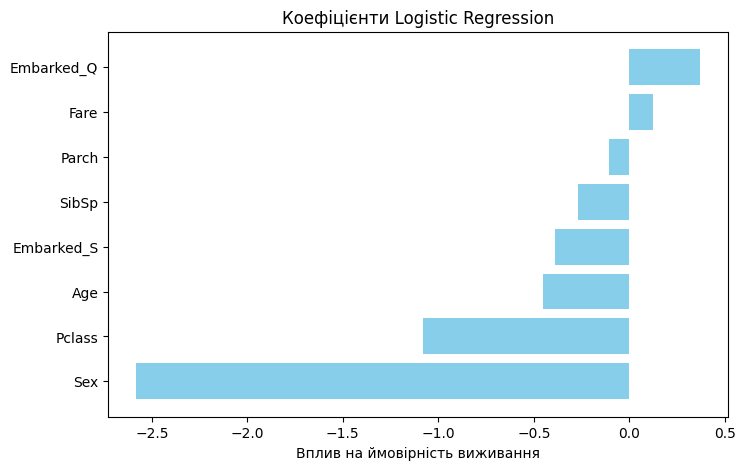

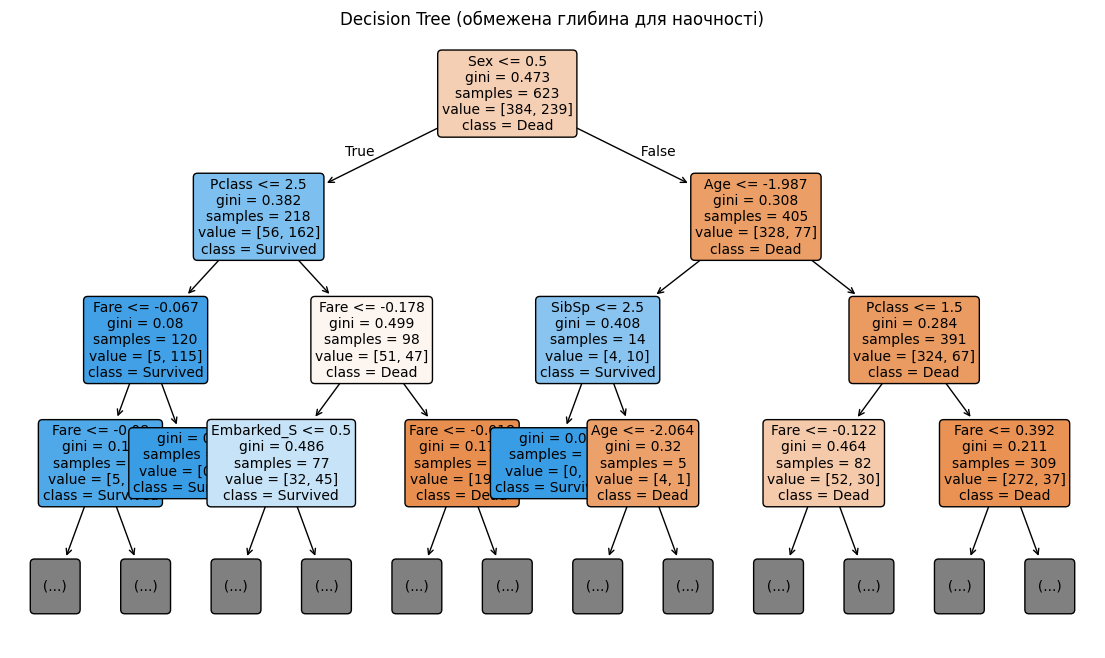

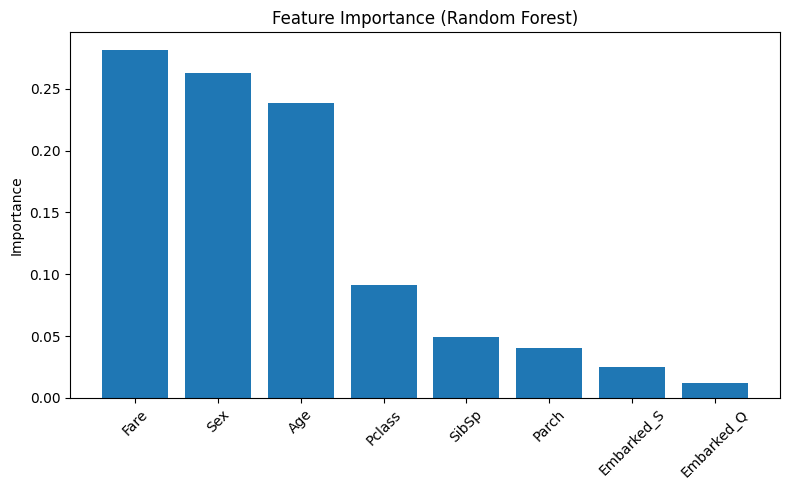

In [23]:
# --- Visualization of model trainingй ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1️⃣ Logistic Regression — coefficients of the model
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xlabel('Вплив на ймовірність виживання')
plt.title('Коефіцієнти Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

# 2️⃣ Decision Tree — tree structure (limited depth)
plt.figure(figsize=(14, 8))
plot_tree(
    tree_clf,
    feature_names=X_train.columns,
    class_names=['Dead', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree (обмежена глибина для наочності)")
plt.show()

# 3️⃣ Random Forest — feature importance
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=45)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


=== Метрики моделей (Validation set) ===
                Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8209     0.7414  0.8269    0.7818   0.8925
1        Decision Tree    0.8358     0.7778  0.8077    0.7925   0.8428
2        Random Forest    0.8507     0.7667  0.8846    0.8214   0.9117


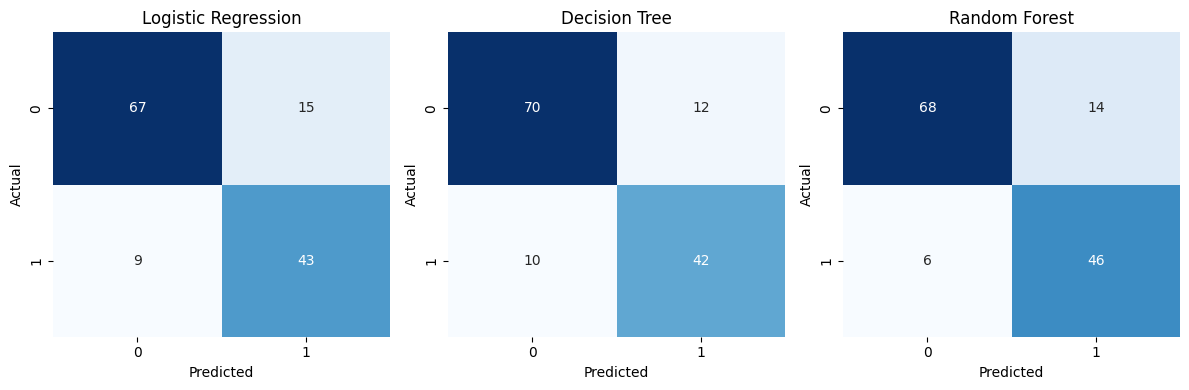

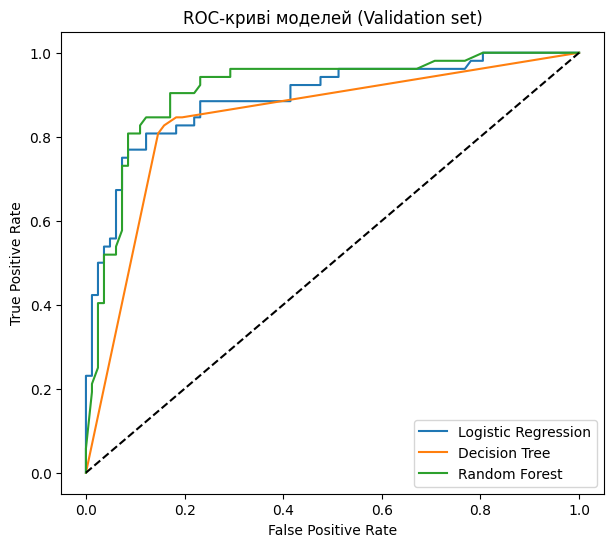

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluation Function ---
def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    return {
        "Модель": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    }

# Compute metrics
results = []
results.append(evaluate_model("Logistic Regression", y_val, val_preds_log, val_proba_log))
results.append(evaluate_model("Decision Tree", y_val, val_preds_tree, val_proba_tree))
results.append(evaluate_model("Random Forest", y_val, val_preds_rf, val_proba_rf))

results_df = pd.DataFrame(results)
print("=== Метрики моделей (Validation set) ===")
print(results_df)

# --- Confusion Matrices ---
models = {
    "Logistic Regression": val_preds_log,
    "Decision Tree": val_preds_tree,
    "Random Forest": val_preds_rf
}

plt.figure(figsize=(12,4))
for i, (name, preds) in enumerate(models.items()):
    plt.subplot(1,3,i+1)
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- ROC Curve ---
plt.figure(figsize=(7,6))
for name, (preds, proba) in {
    "Logistic Regression": (val_preds_log, val_proba_log),
    "Decision Tree": (val_preds_tree, val_proba_tree),
    "Random Forest": (val_preds_rf, val_proba_rf)
}.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0,1], [0,1], "k--")
plt.title("ROC-криві моделей (Validation set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [25]:
# Phase 5: Hyperparameter Tuning & Cross-Validation
# To improve generalization and prevent overfitting, we perform hyperparameter optimization using GridSearchCV on the Decision Tree model, 
# followed by Cross-Validation to ensure stability.

Найкращі параметри Decision Tree: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
=== Порівняння продуктивності Decision Tree ===
                         Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC
0        Decision Tree (базова)     0.836      0.778   0.808     0.792    0.843
1  Decision Tree (оптимізована)     0.843      0.792   0.808     0.800    0.880

Крос-валідаційні оцінки (Accuracy) оптимізованої моделі: [0.816      0.872      0.832      0.78225806 0.82258065]
Середнє значення Accuracy: 0.824967741935484
Стандартне відхилення Accuracy: 0.028885017305964513


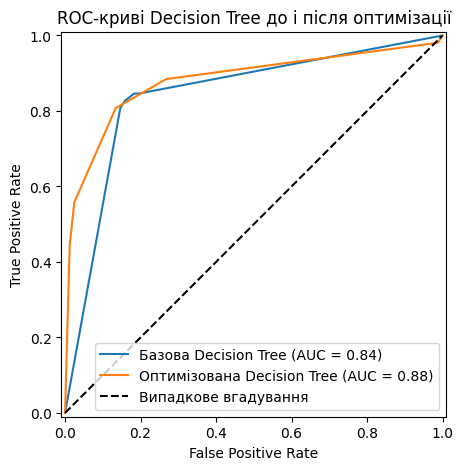

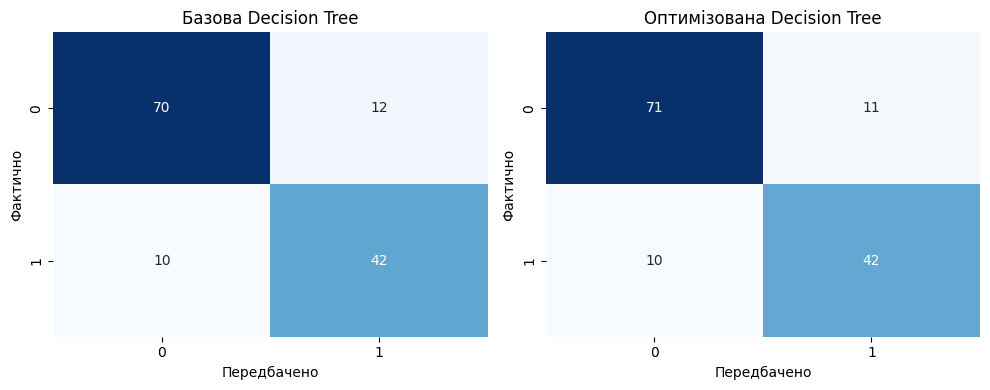

In [43]:

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import RocCurveDisplay, confusion_matrix
import seaborn as sns

# Base model Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_val_pred_base = dt_base.predict(X_val)
y_val_proba_base = dt_base.predict_proba(X_val)[:, 1]

results = []
results.append(evaluate_model("Decision Tree (базова)", y_val, y_val_pred_base, y_val_proba_base))

# Define hyperparameter grid for Decision Tree
param_grid = {
    'max_depth': [None, 3, 5, 7, 9],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Initialize and run GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Найкращі параметри Decision Tree:", best_params)

# --- Train Optimized Model ---
dt_opt = DecisionTreeClassifier(**best_params, random_state=42)
dt_opt.fit(X_train, y_train)

y_val_pred_opt = dt_opt.predict(X_val)
y_val_proba_opt = dt_opt.predict_proba(X_val)[:, 1]

results.append(evaluate_model("Decision Tree (оптимізована)", y_val, y_val_pred_opt, y_val_proba_opt))

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 10)

# Гарантуємо правильний тип і ключі без пробілів
results_df = pd.DataFrame([
    {
        "Модель": r["Модель"],
        "Accuracy": float(r["Accuracy"]),
        "Precision": float(r["Precision"]),
        "Recall": float(r["Recall"]),
        "F1-score": float(r["F1-score"]),
        "ROC-AUC": float(r["ROC-AUC"])  # обов'язково float
    } for r in results
]).round(3)  # округлюємо для зручності

print("=== Порівняння продуктивності Decision Tree ===")
print(results_df)


# --- Cross-Validation Check ---
cv_scores = cross_val_score(dt_opt, X_train, y_train, cv=5, scoring='accuracy')
print("\nКрос-валідаційні оцінки (Accuracy) оптимізованої моделі:", cv_scores)
print("Середнє значення Accuracy:", cv_scores.mean())
print("Стандартне відхилення Accuracy:", cv_scores.std())

# --- ROC Curve Comparison ---
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba_base,
    name="Базова Decision Tree",
    ax=ax
)
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba_opt,
    name="Оптимізована Decision Tree",
    ax=ax
)

# Additionally, we correct the legend and axes.
ax.plot([0, 1], [0, 1], 'k--', label='Випадкове вгадування')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-криві Decision Tree до і після оптимізації")
ax.legend()
plt.show()



# Confusion matrices for the basic and optimized models
plt.figure(figsize=(10,4))
for i, (name, y_pred) in enumerate({
    "Базова Decision Tree": y_val_pred_base,
    "Оптимізована Decision Tree": y_val_pred_opt
}.items()):
    plt.subplot(1,2,i+1)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel("Передбачено")
    plt.ylabel("Фактично")
plt.tight_layout()
plt.show()
